# UAC Care Pipeline Analysis

This project analyzes the efficiency of the Unaccompanied Alien Children (UAC) care pipeline by evaluating transitions between CBP custody, HHS care, and sponsor placement.

The goal is to identify bottlenecks, measure efficiency, and improve reunification outcomes using data-driven insights.

The care transition system operates as a multi-stage pipeline, where delays in later stages directly impact earlier stages. Even if transfers are efficient, slow discharges can cause backlog accumulation throughout the system.

In [2]:
#IMPORT LIBRARIES

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

The dataset was loaded and the Date column was parsed during loading to enable time-series analysis.

In [3]:
df = pd.read_csv('../data/HHS_Unaccompanied_Alien_Children_Program.csv', parse_dates=['Date'])
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2025-12-21,6.0,18.0,11.0,"2,484",14.0
1,2025-12-18,11.0,50.0,6.0,"2,472",16.0
2,2025-12-17,7.0,31.0,11.0,"2,481",10.0
3,2025-12-16,8.0,54.0,15.0,"2,468",9.0
4,2025-12-15,11.0,42.0,9.0,"2,470",7.0


## Initial Data Inspection

The dataset contained duplicate rows and missing values across multiple columns. These issues were addressed in the data cleaning stage.

In [4]:
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Date                                             720 non-null    datetime64[ns]
 1   Children apprehended and placed in CBP custody*  720 non-null    float64       
 2   Children in CBP custody                          720 non-null    float64       
 3   Children transferred out of CBP custody          720 non-null    float64       
 4   Children in HHS Care                             720 non-null    object        
 5   Children discharged from HHS Care                720 non-null    float64       
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 55.0+ KB


449

In [5]:
#check the total rows and columns in the dataset
df.shape

(1170, 6)

## Data Cleaning

- Removed duplicate rows
- Dropped null values
- Sorted data by date
- Renamed columns for better readability

In [6]:
#Duplicate rows were removed to avoid double-counting of records.

df = df.drop_duplicates()
df.shape

(721, 6)

In [7]:
df.isnull().sum()

Date                                               1
Children apprehended and placed in CBP custody*    1
Children in CBP custody                            1
Children transferred out of CBP custody            1
Children in HHS Care                               1
Children discharged from HHS Care                  1
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 721 entries, 0 to 720
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Date                                             720 non-null    datetime64[ns]
 1   Children apprehended and placed in CBP custody*  720 non-null    float64       
 2   Children in CBP custody                          720 non-null    float64       
 3   Children transferred out of CBP custody          720 non-null    float64       
 4   Children in HHS Care                             720 non-null    object        
 5   Children discharged from HHS Care                720 non-null    float64       
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 39.4+ KB


In [9]:
#Removed null row, since it is found null across all the columns. it is removed to protect data integrity.

df = df.dropna()
df.shape

(720, 6)

In [10]:
#checking if there is any null value left

df.isnull().sum()

Date                                               0
Children apprehended and placed in CBP custody*    0
Children in CBP custody                            0
Children transferred out of CBP custody            0
Children in HHS Care                               0
Children discharged from HHS Care                  0
dtype: int64

In [11]:
#Data was sorted by date to ensure chronological order, which is essential for accurate time-series analysis 
#and trend visualization.

df = df.sort_values(by='Date')

In [12]:
#changed the Children in HHS Care data type from object to float.

df['Children in HHS Care'] = df['Children in HHS Care'].astype(str).str.replace(',', '')
df['Children in HHS Care'] = df['Children in HHS Care'].astype(float)

In [13]:
#Column names were renamed to improve readability, ensure consistency using snake_case format, and simplify coding.

df = df.rename(columns= {
    'Children apprehended and placed in CBP custody*' : 'cbp_apprehended',
    'Children in CBP custody' : 'cbp_custody',
    'Children transferred out of CBP custody' : 'cbp_transferred',
    'Children in HHS Care' : 'hhs_care',
    'Children discharged from HHS Care' : 'hhs_discharged'
})

## Exploratory Data Analysis (EDA)

Initial exploration was performed to understand trends in CBP custody, HHS care, and overall system flow before deriving performance metrics.

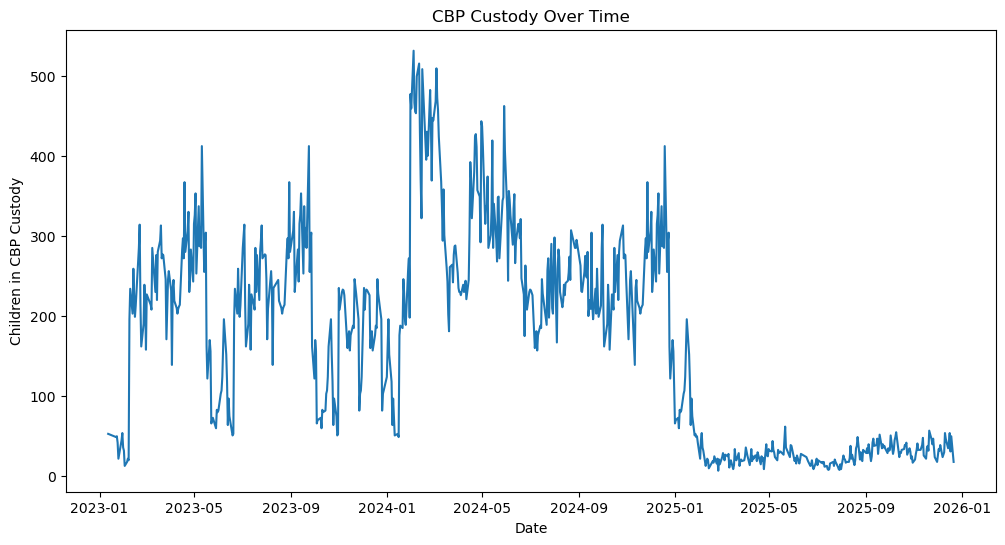

In [14]:
#CBP Custody Trend
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['cbp_custody'])

plt.title("CBP Custody Over Time")
plt.xlabel("Date")
plt.ylabel("Children in CBP Custody")

plt.savefig('../VISUALS/cbp_custody_over_time_trend.png', bbox_inches='tight', dpi=150)
plt.show()

#CBP custody trend shows how many children remain in initial holding. Rising values may indicate delays in transferring children to HHS care.
#CBP custody levels increased over time, indicating backlog accumulation, and peaked around 2024. 
#A sharp decline in 2025 suggests improved system efficiency and backlog clearance through faster transitions to HHS care.

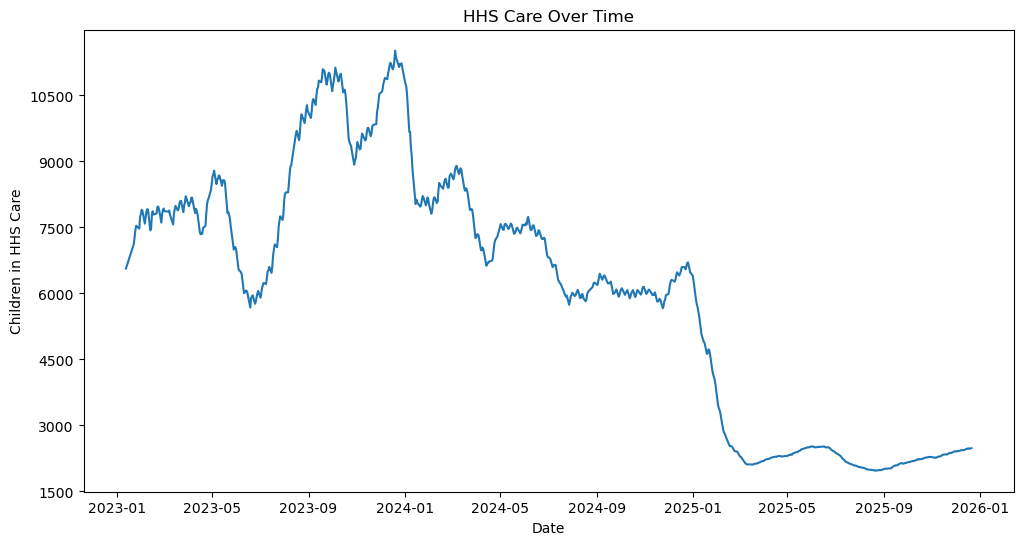

In [15]:
#HHS Care Trend
plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['hhs_care'])
plt.gca(). yaxis.set_major_locator(plt.MaxNLocator(7))
plt.title("HHS Care Over Time")
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")

plt.savefig('../VISUALS/HHS_Care_over_time.png', bbox_inches='tight', dpi=150)
plt.show()

#HHS care represents children under processing. Increasing values may indicate slower discharge or growing backlog in the system.
#HHS Carelevels increased over time, indicating backlog accumulation, and peaked around end of 2023 and in 2024. 
#A sharp decline in 2025 suggests improved system efficiency and backlog clearance started.

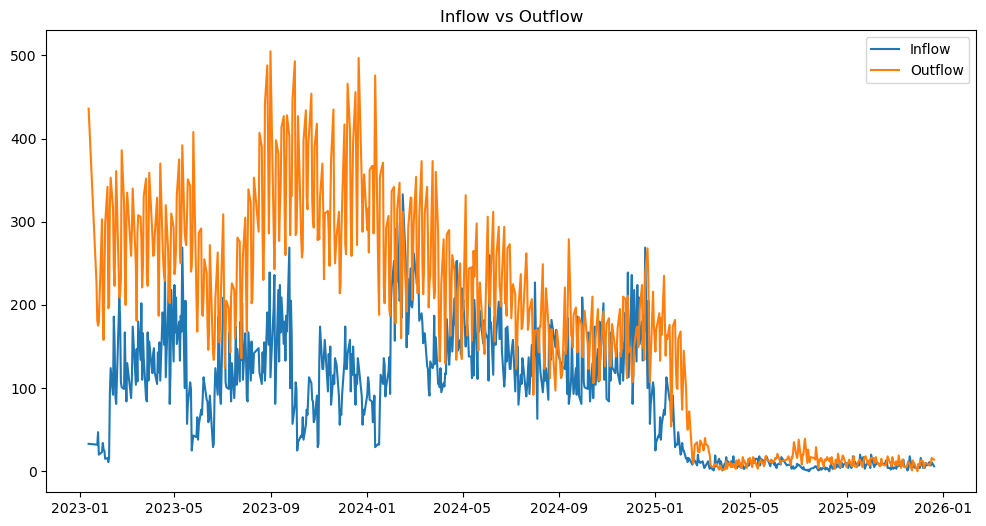

In [16]:
#Inflow vs Outflow

plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['cbp_apprehended'], label='Inflow')
plt.plot(df['Date'], df['hhs_discharged'], label='Outflow')

plt.legend()
plt.title("Inflow vs Outflow")

plt.savefig('../VISUALS/inflow_vs_outflow.png', bbox_inches='tight', dpi=150)
plt.show()

#The inflow of children into the system often exceeds the number of discharges. This imbalance leads to accumulation within the pipeline and 
#contributes to the overall backlog.
#During 2023–early 2024, outflow consistently exceeded inflow, indicating strong system throughput. However, by mid-2024, the gap narrowed, 
#suggesting increasing system pressure. A sharp decline in both inflow and outflow is observed around 2025, indicating a reduction in overall system 
#activity rather than purely improved efficiency. Post-2025, the system stabilizes at a lower operational level.

The simultaneous decline in both inflow and outflow around 2025 suggests a systemic shift affecting overall pipeline activity, rather than isolated efficiency gains. This indicates that backlog reduction was likely driven by reduced inflow alongside operational adjustments.

## KPI Calculation

Key performance indicators were derived to evaluate the efficiency of transitions, discharge outcomes, throughput rate and backlog formation in the care pipeline.

In [ ]:
#Transfer Efficiency Ratio = Transfers ÷ CBP Custody
#Measures how quickly children move from CBP to HHS

df['transfer_efficiency_ratio'] = np.where(df["cbp_custody"] != 0, df["cbp_transferred"] / df["cbp_custody"], np.nan)

In [18]:
total_transfer_efficiency = (
    df['cbp_transferred'].sum() /
    df['cbp_custody'].sum()
)
print(f"Total Transfer Efficiency: {total_transfer_efficiency:.4f}")

Total Transfer Efficiency: 0.7503


In [ ]:
# Discharge Effectiveness = Discharges ÷ HHS Care

df['discharge_effectiveness'] = np.where(df["hhs_care"] != 0, df["hhs_discharged"] / df["hhs_care"], np.nan)

In [20]:
total_discharge_effectiveness = (
    df['hhs_discharged'].sum() /
    df['hhs_care'].sum()
)
print(f"Total Discharge Effectiveness: {total_discharge_effectiveness:.4f}")

Total Discharge Effectiveness: 0.0286


In [21]:
# Pipeline Throughput Rate = Total exits ÷ Total entries
#NumPy where is used to avoid division by zero by calculating the ratio only when inflow is non-zero, otherwise assigning NaN.

df['daily_throughput_rate'] = np.where(
    df['cbp_apprehended'] != 0,
    df['hhs_discharged'] / df['cbp_apprehended'],
    np.nan
)

In [22]:
#Backlog Accumulation Rate
#The backlog represents the number of children remaining in the system after accounting for discharges. 
#A consistently high backlog indicates that inflow is exceeding outflow, leading to accumulation within the system.
#A declining backlog trend suggests improvement in system efficiency and better handling of incoming cases.

df['backlog'] = df['cbp_apprehended'] - df['hhs_discharged']

In [23]:
summary = df[['transfer_efficiency_ratio', 'discharge_effectiveness', 
              'daily_throughput_rate', 'backlog']].describe().round(3)
print(summary)

       transfer_efficiency_ratio  discharge_effectiveness  \
count                    720.000                  720.000   
mean                       0.691                    0.024   
std                        0.310                    0.013   
min                        0.000                    0.000   
25%                        0.500                    0.009   
50%                        0.704                    0.026   
75%                        0.846                    0.033   
max                        2.300                    0.066   

       daily_throughput_rate  backlog  
count                718.000  720.000  
mean                   2.503  -79.883  
std                    2.470   98.049  
min                    0.000 -447.000  
25%                    1.153 -139.250  
50%                    1.779  -48.500  
75%                    2.878   -4.000  
max                   21.375  121.000  


# KPI VISUALIZATION

In this section, we analyze key performance indicators (KPIs) of the care transition pipeline to understand system efficiency, bottlenecks, and overall throughput.

The KPIs analyzed include:
- Transfer Efficiency Ratio
- Discharge Effectiveness
- Pipeline Throughput Rate

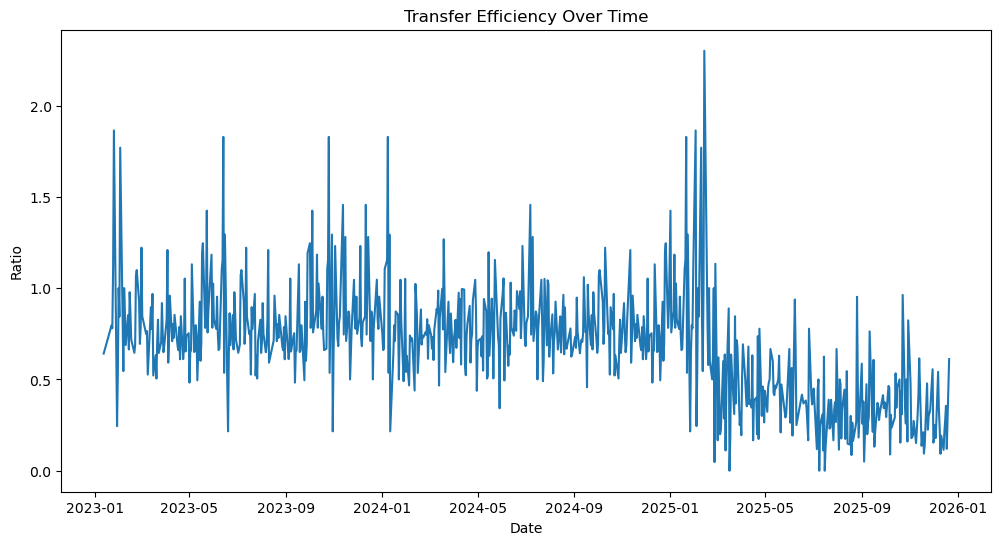

In [24]:
#Transfer Efficiency Trend

plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['transfer_efficiency_ratio'])

plt.title("Transfer Efficiency Over Time")
plt.xlabel("Date")
plt.ylabel("Ratio")

plt.savefig('../VISUALS/transfer_efficiency_ratio.png', bbox_inches='tight', dpi=150)
plt.show()

#Insight
#The transfer efficiency shows significant fluctuations over time, indicating inconsistency in the movement of children from CBP to HHS care.
#Overall, the efficiency remains relatively low, suggesting that transfers are not occurring at an optimal rate.
#Additionally, a noticeable decline in efficiency is observed in the later period, indicating worsening performance in the transfer process.

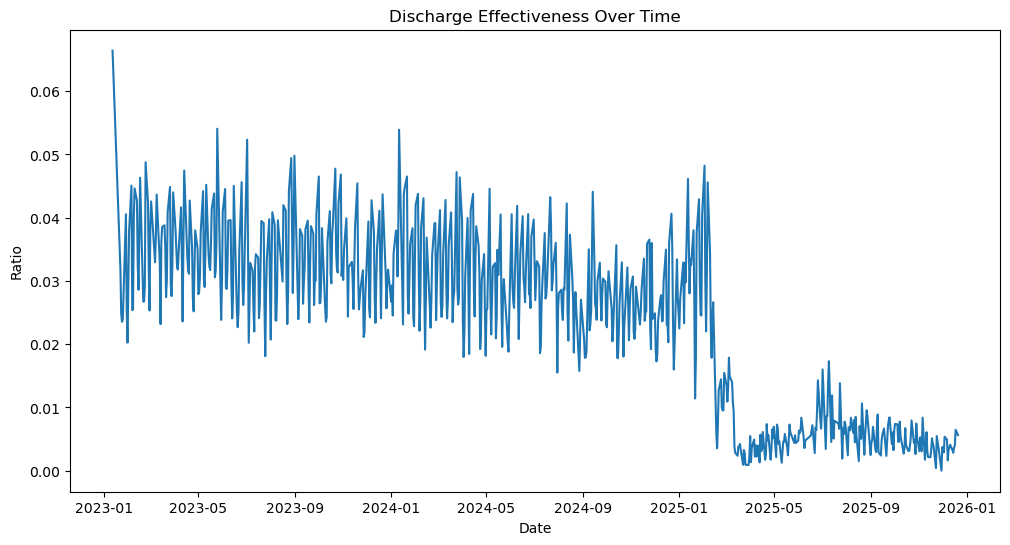

In [48]:
#Discharge Effectiveness Trend

plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['discharge_effectiveness'])

plt.title("Discharge Effectiveness Over Time")
plt.xlabel("Date")
plt.ylabel("Ratio")

plt.savefig('../VISUALS/discharge_effectiveness.png', bbox_inches='tight', dpi=150)
plt.show()

# Insight
#The system does not show strong performance at any stage, as discharge effectiveness remains consistently low throughout the timeline.
#Over time, a gradual decline is observed, indicating that the system is becoming less efficient in placing children with sponsors.
#By 2025, discharge effectiveness drops significantly, suggesting a severe slowdown in the placement process and increasing system strain.

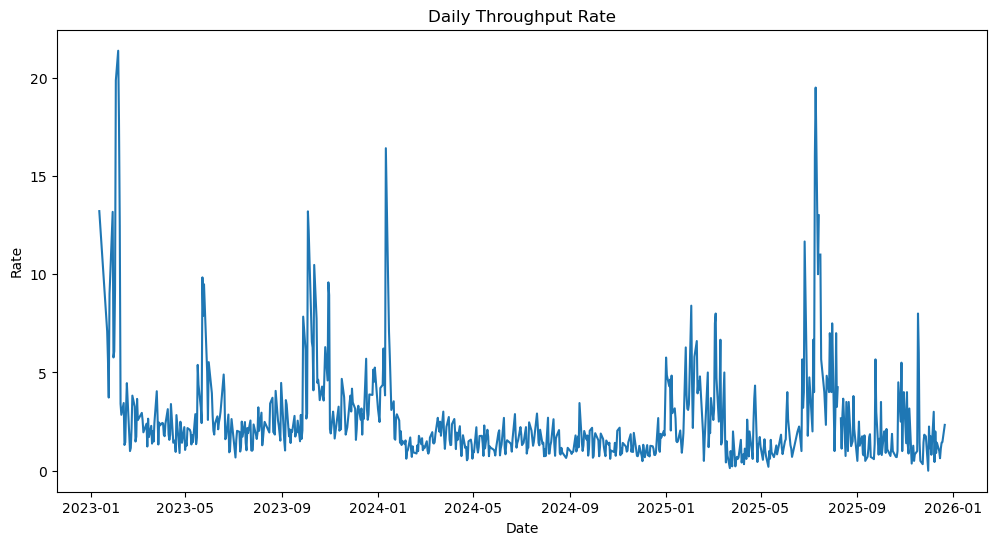

In [49]:
#Pipeline Throughput Trend

plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['daily_throughput_rate'])

plt.title("Daily Throughput Rate")
plt.xlabel("Date")
plt.ylabel("Rate")

plt.savefig('../VISUALS/daily_throughput_rate.png', bbox_inches='tight', dpi=150)
plt.show()

#The daily throughput rate shows high variability, indicating that the system is not operating in a stable or consistent manner.
#There are frequent fluctuations, with occasional spikes where a large number of children are discharged, suggesting periodic backlog clearance.
#However, during most periods, the throughput remains relatively low, indicating that daily inflow often exceeds outflow, contributing to backlog accumulation.
#Overall, the system exhibits inconsistent performance with intermittent improvements but lacks sustained efficiency.

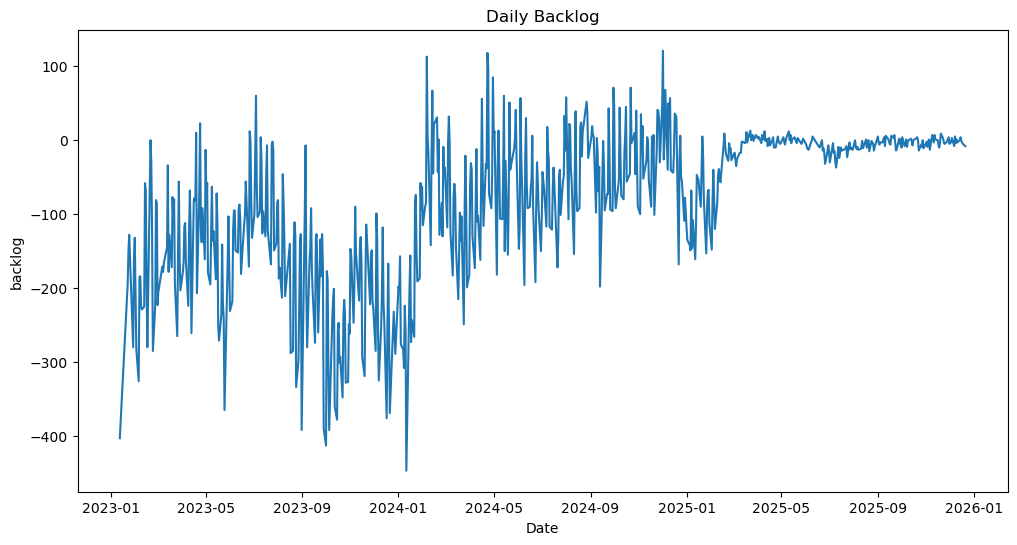

In [50]:
#Backlog Trend

plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['backlog'])

plt.title("Daily Backlog")
plt.xlabel("Date")
plt.ylabel("backlog")

plt.savefig('../VISUALS/backlog.png', bbox_inches='tight', dpi=150)
plt.show()

# Insight
#The daily backlog values are predominantly negative, indicating that the system is consistently discharging more children than new arrivals, 
#leading to a reduction in pending cases.
#However, the backlog trend shows high variability during earlier periods, suggesting inconsistent processing rates.
#In the later period (around 2025), backlog values stabilize near zero, indicating that inflow and outflow are nearly balanced, leading to a 
#stagnation in backlog reduction.

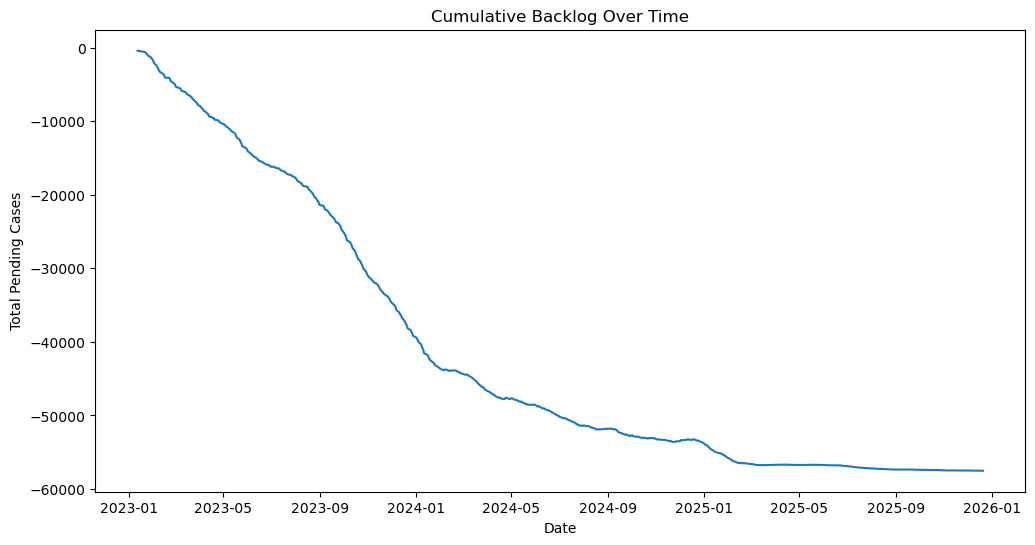

In [51]:
#Cumulative Backlog Analysis

df['cumulative_backlog'] = df['backlog'].cumsum()

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['cumulative_backlog'])

plt.title("Cumulative Backlog Over Time")
plt.xlabel("Date")
plt.ylabel("Total Pending Cases")

plt.savefig('../VISUALS/cumulative_backlog.png', bbox_inches='tight', dpi=150)
plt.show()

#While cumulative backlog continues to decrease (indicating that discharges exceed new arrivals), the rate of reduction slows significantly over time, 
#as observed from the flattening of the curve.

## Bottleneck Detection Analysis

This section identifies where delays occur in the care pipeline by comparing stage-level care loads with movement and discharge outcomes.

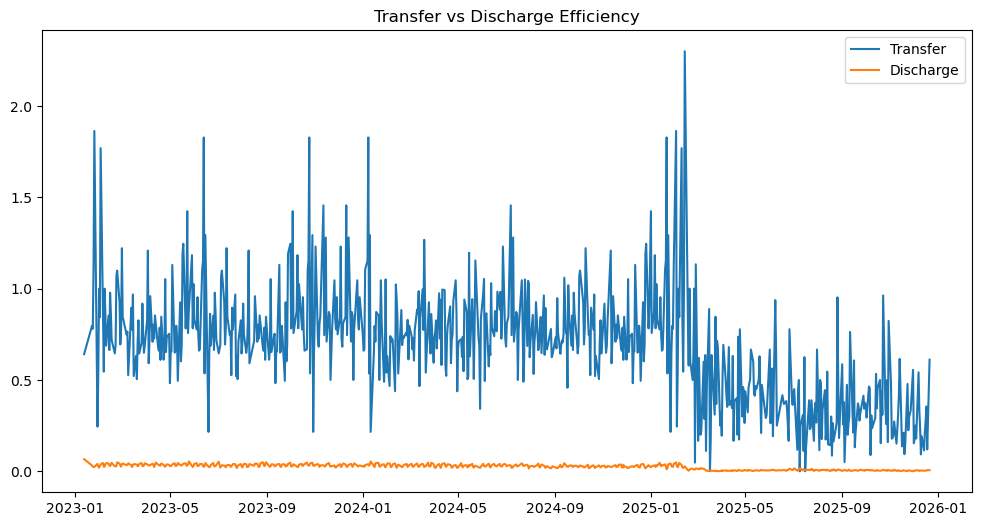

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['transfer_efficiency_ratio'], label='Transfer')
plt.plot(df['Date'], df['discharge_effectiveness'], label='Discharge')

plt.legend()
plt.title("Transfer vs Discharge Efficiency")

plt.savefig('../VISUALS/transfer_and discharge_effectiveness.png', bbox_inches='tight', dpi=150)
plt.show()

#While transfers from CBP to HHS occur at a relatively faster pace, discharges lag behind. This imbalance indicates that children are entering 
#the system faster than they are exiting, leading to pressure buildup in later stages.

In [30]:
#Numerical Comparision

avg_transfer = df['transfer_efficiency_ratio'].mean().round(2)
avg_discharge = df['discharge_effectiveness'].mean().round(2)

print('avg_transfer :' ,avg_transfer)
print('avg_discharge :' ,avg_discharge)

avg_transfer : 0.69
avg_discharge : 0.02


### Bottleneck Analysis

The comparison between transfer efficiency and discharge effectiveness clearly indicates that the primary bottleneck exists at the HHS stage.

While the transfer efficiency is relatively moderate (~69%), indicating that children are being moved from CBP to HHS at a reasonable rate, the discharge effectiveness is extremely low (~2%).

This suggests that the major delay occurs in the placement process, where children remain in HHS care for extended periods without being discharged to sponsors.

Overall, the system is able to move children into HHS care, but struggles significantly in completing the final stage of the pipeline.

### Overall System Performance

The system demonstrates partial efficiency in early-stage transitions (CBP to HHS), but fails to maintain performance in the final stage.

Despite some backlog reduction in earlier periods, the declining discharge effectiveness and inconsistent throughput indicate that the system lacks sustained efficiency and stability.

# Temporal & Pattern Analysis

In [31]:
#Weekday column

df['weekday'] = df['Date'].dt.day_name()

In [32]:
#Weekend identification

df['is_weekend'] = df['weekday'].isin(['Saturday', 'Sunday'])
df['day_type']= df['is_weekend'].map({True: 'Weekend', False : 'Weekday'})

In [33]:
week_analysis = df.groupby('day_type')['daily_throughput_rate'].mean().round(2)
week_analysis

day_type
Weekday    2.47
Weekend    2.68
Name: daily_throughput_rate, dtype: float64

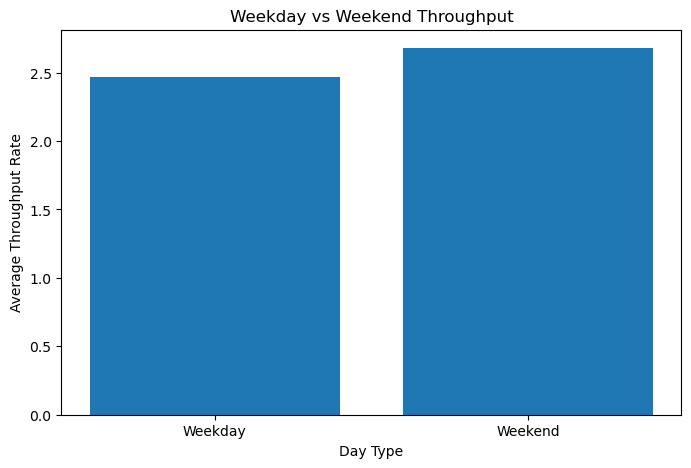

In [53]:
plt.figure(figsize=(8,5))

plt.bar(week_analysis.index, week_analysis.values)

plt.title("Weekday vs Weekend Throughput")
plt.xlabel("Day Type")
plt.ylabel("Average Throughput Rate")

plt.savefig('../VISUALS/Weekday vs Weekend Throughput.png', bbox_inches='tight', dpi=150)
plt.show()


#Weekend throughput is slightly higher than weekday throughput, but the difference is small. This suggests that throughput does not vary 
#strongly by day type

In [35]:
#Month Column 

df['month'] = df['Date'].dt.to_period('M')

In [36]:
monthly_trend = df.groupby('month')['discharge_effectiveness'].mean()

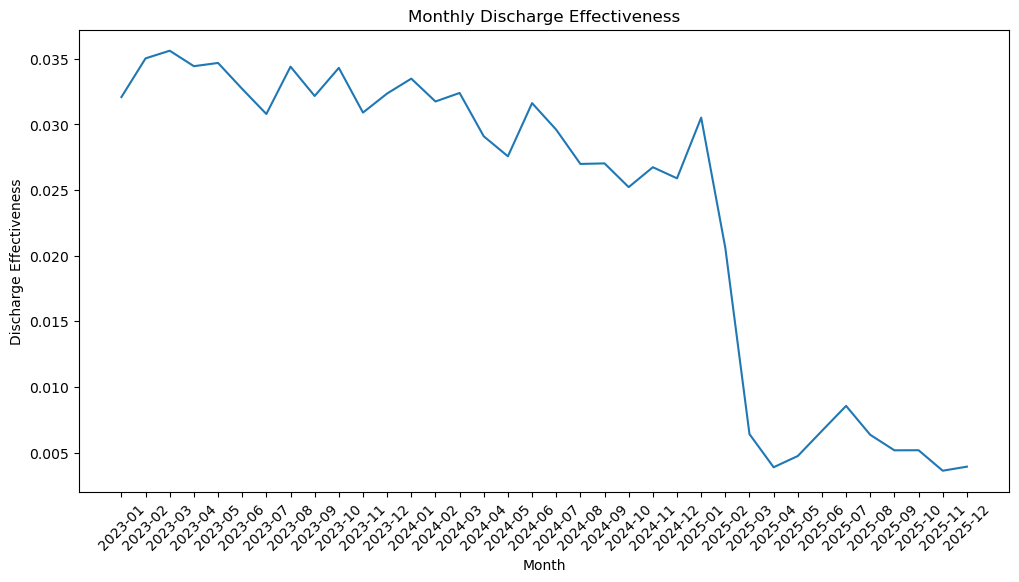

In [54]:
plt.figure(figsize=(12,6))

plt.plot(monthly_trend.index.astype(str), monthly_trend.values)

plt.title("Monthly Discharge Effectiveness")
plt.xlabel("Month")
plt.ylabel("Discharge Effectiveness")
plt.xticks(rotation=45)

plt.savefig('../VISUALS/Monthly_Discharge_Effectiveness.png', bbox_inches='tight', dpi=150)
plt.show()

### Month-over-Month Trend Analysis

The monthly trend of discharge effectiveness shows a clear declining pattern over time.

Initially, the system demonstrates relatively stable and higher discharge performance. However, a gradual decline is observed throughout 2024, indicating weakening efficiency in placement outcomes.

A significant drop occurs in early 2025, where discharge effectiveness falls sharply, suggesting a major slowdown in the system.

In the later period, the trend remains consistently low, indicating prolonged stagnation with no substantial recovery in performance.

### Identification of Prolonged Stagnation Periods

The analysis identifies a prolonged stagnation period during 2025, where discharge effectiveness remains consistently low with minimal variation.

This indicates that the system is no longer improving or recovering, and has reached a performance plateau at a low efficiency level. The persistence of this stagnation highlights a sustained bottleneck in the placement process.

In [38]:
#To identify stagnation periods, we calculated a 7-day rolling average of discharge effectiveness. 
#Periods where the rolling discharge effectiveness remained very low were treated as stagnation periods.

df['rolling_discharge_effectiveness'] = df['discharge_effectiveness'].rolling(window=7).mean()

stagnation_threshold = df['rolling_discharge_effectiveness'].quantile(0.25)

df['stagnation_period'] = df['rolling_discharge_effectiveness'] < stagnation_threshold

df[['Date', 'discharge_effectiveness', 'rolling_discharge_effectiveness', 'stagnation_period']].head()

,Date,discharge_effectiveness,rolling_discharge_effectiveness,stagnation_period
719,2023-01-12,0.066403,NaN,False
718,2023-01-22,0.031873,NaN,False
717,2023-01-23,0.024863,NaN,False
716,2023-01-24,0.023544,NaN,False
715,2023-01-25,0.023879,NaN,False


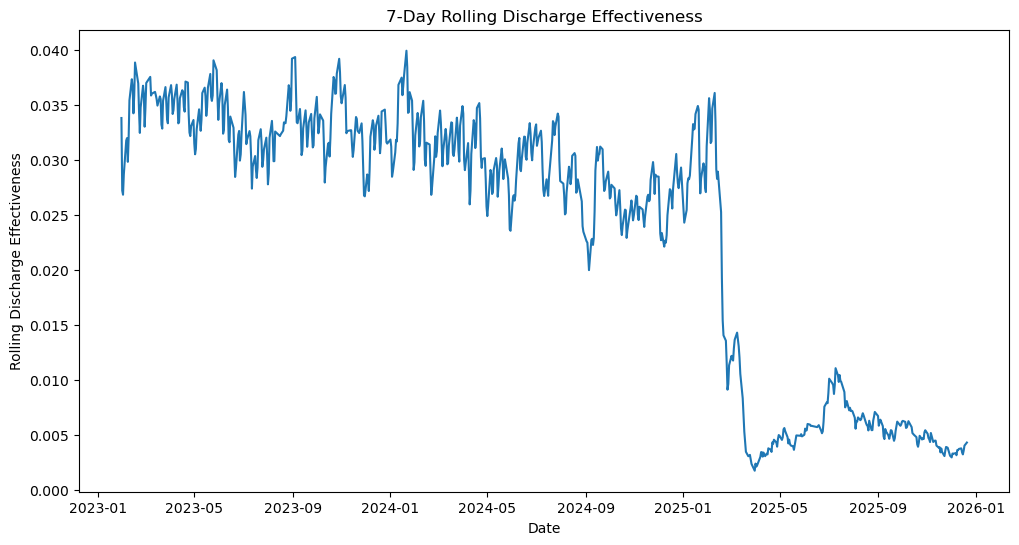

In [55]:
plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['rolling_discharge_effectiveness'])

plt.title("7-Day Rolling Discharge Effectiveness")
plt.xlabel("Date")
plt.ylabel("Rolling Discharge Effectiveness")

plt.savefig('../VISUALS/7-Day_Rolling_Discharge_Effectiveness.png', bbox_inches='tight', dpi=150)
plt.show()

## Outcome Stability Analysis

### Variability in Discharge Performance

The analysis shows significant variability in discharge effectiveness, with frequent fluctuations and sudden spikes. This indicates that the system lacks stability and operates inconsistently over time.

---

### Consistency of Placement Outcomes

The system does not demonstrate consistent placement performance. While early periods show relatively stable outcomes, performance declines over time and fails to recover, indicating a lack of reliability in the placement process.

---

### Sudden Drops in Reunification Success

A sharp decline in discharge effectiveness is observed in early 2025, indicating a sudden drop in reunification success. This suggests a potential system disruption or breakdown in the placement process during that period.

In [40]:
df['discharge_change'] = df['discharge_effectiveness'].diff()

drop_threshold = df['discharge_change'].quantile(0.10)

df['sudden_drop'] = df['discharge_change'] < drop_threshold

df[['Date', 'discharge_effectiveness', 'discharge_change', 'sudden_drop']].head()

#Periods of high variability in discharge performance often align with sudden drops, indicating instability in the system. 
#This suggests that the pipeline lacks consistent operational efficiency over time.

,Date,discharge_effectiveness,discharge_change,sudden_drop
719,2023-01-12,0.066403,NaN,False
718,2023-01-22,0.031873,-0.034530,True
717,2023-01-23,0.024863,-0.007010,False
716,2023-01-24,0.023544,-0.001319,False
715,2023-01-25,0.023879,0.000335,False


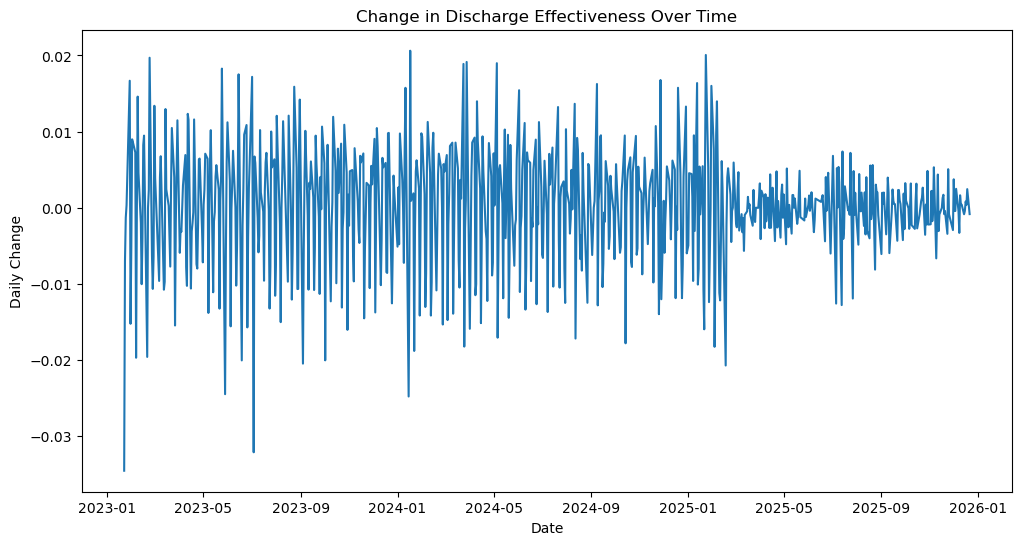

In [56]:
plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['discharge_change'])

plt.title("Change in Discharge Effectiveness Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Change")

plt.savefig('../VISUALS/Change_in_Discharge_Effectiveness_Over_Time.png', bbox_inches='tight', dpi=150)
plt.show()

#Sudden negative changes in discharge effectiveness indicate days where placement performance dropped sharply. 
#These drops may represent operational slowdowns or periods of reduced discharge activity.

In [42]:
df['outcome_stability_score'] = df['discharge_effectiveness'].rolling(window=7).std()
print(f"Average Outcome Stability Score: {df['outcome_stability_score'].mean():.4f}")

Average Outcome Stability Score: 0.0055


In [43]:
stability_summary = df['outcome_stability_score'].describe().round(4)
stability_summary

count    714.0000
mean       0.0055
std        0.0027
min        0.0005
25%        0.0033
50%        0.0060
75%        0.0074
max        0.0156
Name: outcome_stability_score, dtype: float64

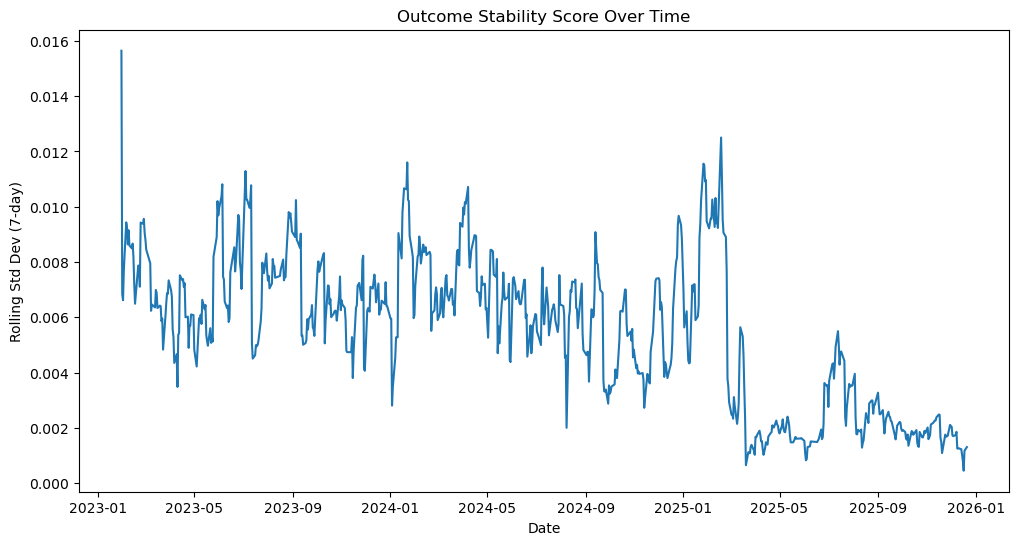

In [57]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['outcome_stability_score'])
plt.title("Outcome Stability Score Over Time")
plt.xlabel("Date")
plt.ylabel("Rolling Std Dev (7-day)")

plt.savefig('../VISUALS/Outcome_Stability_Score_Over_Time.png', bbox_inches='tight', dpi=150)
plt.show()

In [45]:
df['inflow'] = df['cbp_apprehended']
df['outflow'] = df['hhs_discharged']
df['net_flow'] = df['inflow'] - df['outflow']

In [46]:
kpi_summary = pd.DataFrame({
    'KPI': [
        'Average Transfer Efficiency',
        'Average Discharge Effectiveness',
        'Average Daily Throughput Rate',
        'Average Daily Backlog',
        'Average Outcome Stability Score'
    ],
    'Value': [
        df['transfer_efficiency_ratio'].mean(),
        df['discharge_effectiveness'].mean(),
        df['daily_throughput_rate'].mean(),
        df['backlog'].mean(),
        df['outcome_stability_score'].mean()
    ]
})

kpi_summary['Value'] = kpi_summary['Value'].round(4)
kpi_summary

,KPI,Value
0,Average Transfer Efficiency,0.6910
1,Average Discharge Effectiveness,0.0237
2,Average Daily Throughput Rate,2.5032
3,Average Daily Backlog,-79.8833
4,Average Outcome Stability Score,0.0055


## Final Conclusion

The UAC care pipeline shows partial efficiency in early-stage transitions from CBP custody to HHS care. However, discharge effectiveness remains much lower, indicating that the major bottleneck exists at the HHS discharge and sponsor placement stage.

The analysis also shows that throughput is inconsistent over time, with periods of fluctuation, slowdown, and stagnation. While backlog reduction is visible in some periods, the decline in discharge effectiveness suggests that placement outcomes are not improving consistently.

Overall, the system appears to face stronger challenges in completing the final stage of the pipeline than in moving children from CBP custody into HHS care.

In [47]:
df.to_csv('../data/uac_cleaned_kpi_dataset.csv', index=False)